In [1]:
import pandas as pd
import sys
sys.path.extend(['/Users/amonast/Documents/GitHub/Engram_2P/Engram_2P/utilities'])
from traces import ridge_plot
import animal
import numpy as np
import matplotlib.pyplot as plt
import ast
from scipy.stats import zscore
from scipy.ndimage import gaussian_filter1d
import matplotlib.colors as mcolors

%matplotlib widget

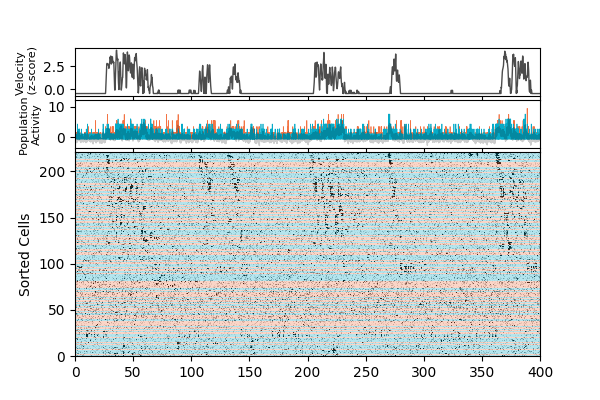

In [ ]:
ani='994R'
fov='FOV1'
base_dir = '/Volumes/AM_SSD1/Spont2P'
file_key = '/Volumes/AM_SSD1/Spont2P/Data_info.csv'

session='Post'
params_dir='nPCs10_lag60_loc0.1_bin15'

##########
isort = np.load(f"{base_dir}/Analysis/rastermap_batch/{params_dir}/{ani}_{session}_{fov}_isort_.npy")
mouse = animal.animal(ani,fov,file_key=file_key,base_dir = base_dir)
traces_df = mouse.load_traces(signal='dff',sessions=[session])
spks = mouse.load_traces(signal='events',sessions=[session]).iloc[:,1:].T.values
velocity = mouse.compute_velocity(sessions=[session],window_size=30)

# Backward-looking window creates a ~window_size//2 lag; center it
shift = 30 // 2  # = 15 frames = 0.5 s at 30 Hz
velocity = np.concatenate([velocity[shift:], np.full(shift, velocity[-1])])

spks=spks>0
vel_smooth = gaussian_filter1d(velocity, sigma=2)

timestamps = traces_df['timestamps'].values
is_engram = [bool(ast.literal_eval(col)[0]) for col in traces_df.columns[1:]]
cell_ids=traces_df.iloc[:,0].reset_index()
dff = traces_df.iloc[:,1:].T.values

# Apply sort
sorted_dff= dff[isort, :]
sorted_engram = np.array(is_engram)[isort]
engram_to_color_dict = {'engram':"#F37343", 'non-engram':"#06ABC8"}
row_colors = [
    engram_to_color_dict['engram'] if e else engram_to_color_dict['non-engram']
    for e in sorted_engram]

sampling_rate=30

act = sorted_dff
sorted_spks = spks
eng_id = sorted_engram[:]
row_colors=row_colors[:]
time=timestamps

fig = plt.figure(figsize=(6,4), dpi=100)
grid = plt.GridSpec(12, 1, figure=fig, wspace = 0.1, hspace = 0.2)
ax0 = fig.add_subplot(grid[0:2, :])
ax1 = fig.add_subplot(grid[2:4, :], sharex=ax0)
ax2 = fig.add_subplot(grid[4:, :], sharex=ax0)

ax0.plot(time, zscore(np.abs(vel_smooth)), color='k', alpha=0.7, linewidth=1)
ax0.set_ylabel('Velocity \n (z-score)',size=8)

ax1.plot(time,zscore(sorted_spks[eng_id].sum(axis=0)),lw=.5,color=engram_to_color_dict['engram'])
ax1.plot(time,zscore(sorted_spks[~eng_id].sum(axis=0)),lw=.5,color=engram_to_color_dict['non-engram'])
ax1.plot(time,zscore(act.sum(axis=0)),lw=1,color='k',alpha=0.2)
ax1.set_ylabel('Population \nActivity',size=8)

n_rows, n_cols = act.shape
extent = [time[0], time[-1], 0, n_rows]

# Grayscale heatmap
ax2.pcolormesh(
    time,
    np.arange(n_rows),
    np.clip(zscore(act, axis=1), 0, 3),
    cmap='gray_r',
    vmin=0, vmax=3,
    shading='nearest',
    zorder=1
)

# Color overlay: 1-column RGBA strip stretched across the full extent.
# Using a single column instead of (n_rows x n_cols x 4) avoids a ~280 MB array.
row_colors_rgba = [mcolors.to_rgba(c, alpha=0.3) for c in row_colors]
color_strip = np.array(row_colors_rgba)[:, np.newaxis, :]  # (n_rows, 1, 4)
ax2.imshow(color_strip, aspect='auto', extent=extent, origin='lower',
           interpolation='nearest', zorder=2)

ax2.set_ylabel('Sorted Cells')
ax0.tick_params(labelbottom=False)
ax1.tick_params(labelbottom=False)
for ax in [ax0,ax1,ax2]:
    ax.set_xlim(0,400)
plt.savefig('rastermap_zoom.png',transparent=True)